# Classificação de Imagens de Raio-X: Pneumonia vs. Saudável

Este notebook aborda a Questão 9 (Avançado) para o desenvolvimento de um modelo de Deep Learning capaz de classificar imagens de raio-X de tórax em duas categorias: **Saudável** e **Pneumonia**. Utilizaremos o dataset fornecido (`Data_Entry_2017.csv`) e implementaremos uma Rede Neural Convolucional (CNN) com técnicas de data augmentation e avaliação de métricas de desempenho.

In [1]:
import numpy as np
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# --- Configurações ---
# ATENÇÃO: Substitua o caminho abaixo pelo caminho real da sua pasta de imagens
IMAGE_DIR = r'C:\Users\jvbrl\Desktop\faculdade\xray' 
CSV_PATH = 'Data_Entry_2017.csv'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 2 # Saudável (No Finding) e Pneumonia

print(f'TensorFlow Version: {tf.__version__}')

TensorFlow Version: 2.21.0


## 1. Carregamento e Pré-processamento dos Dados

Nesta seção, carregamos o arquivo CSV, mapeamos os caminhos das imagens e filtramos os dados para criar um problema de classificação binária entre 'Pneumonia' e 'No Finding'.

In [2]:
# Carregar o CSV
all_xray_df = pd.read_csv(CSV_PATH)

# Mapear caminhos das imagens
all_image_paths = {os.path.basename(x): x for x in glob(os.path.join(IMAGE_DIR, '**', '*.png'), recursive=True)}
print(f'Imagens encontradas: {len(all_image_paths)}, Registros no CSV: {all_xray_df.shape[0]}')

all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

# Remover entradas sem caminho de imagem correspondente
all_xray_df = all_xray_df.dropna(subset=['path'])

# Filtrar para 'Pneumonia' e 'No Finding'
def get_label(labels):
    if 'Pneumonia' in labels:
        return 'Pneumonia'
    elif 'No Finding' in labels:
        return 'No Finding'
    return None

all_xray_df['target'] = all_xray_df['Finding Labels'].apply(get_label)
all_xray_df = all_xray_df.dropna(subset=['target'])

print('\nContagem de classes:')
print(all_xray_df['target'].value_counts())

# Divisão dos dados
train_df, test_df = train_test_split(all_xray_df, test_size=0.2, random_state=42, stratify=all_xray_df['target'])
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42, stratify=train_df['target'])

Imagens encontradas: 4999, Registros no CSV: 112120

Contagem de classes:
target
No Finding    2756
Pneumonia       63
Name: count, dtype: int64


## 2. Geradores de Dados e Data Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='target',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary'
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='target',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='target',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)

Found 1691 validated image filenames belonging to 2 classes.
Found 564 validated image filenames belonging to 2 classes.
Found 564 validated image filenames belonging to 2 classes.


## 3. Construção do Modelo CNN

In [4]:
base_model = MobileNetV2(weights=None, include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1))

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,421,505 (9.24 MB)

 Trainable params: 2,387,393 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

## 4. Treinamento

In [5]:
callbacks = [
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9633 - loss: 0.1723 - val_accuracy: 0.9770 - val_loss: 0.6389
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9781 - loss: 0.1347 - val_accuracy: 0.9770 - val_loss: 0.4851
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9781 - loss: 0.1230 - val_accuracy: 0.9770 - val_loss: 0.3206
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9781 - loss: 0.1241 - val_accuracy: 0.9770 - val_loss: 0.2524
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9781 - loss: 0.1146 - val_accuracy: 0.9770 - val_loss: 0.1621
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9781 - loss: 0.1232 - val_accuracy: 0.9770 - val_loss: 0.1334
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9781 - loss: 0.1102 - val_accuracy: 0.9770 - val_loss: 0.1234
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9781 - loss: 0.1271 - val_accuracy: 0.9770 - val_loss

## 5. Avaliação

18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 564ms/step
Relatório de Classificação (Threshold: 0.5):
              precision    recall  f1-score   support

  No Finding       0.98      1.00      0.99       551
   Pneumonia       0.00      0.00      0.00        13

    accuracy                           0.98       564
   macro avg       0.49      0.50      0.49       564
weighted avg       0.95      0.98      0.97       564



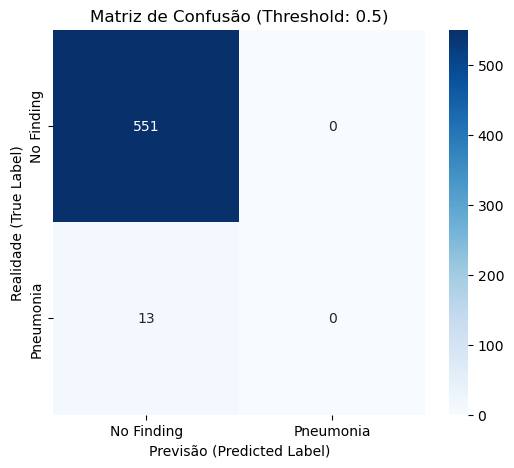

In [7]:
# 1. Definir um limiar de decisão (Threshold)
# Se o modelo não estiver prevendo pneumonia, tente baixar para 0.3 ou 0.4
threshold = 0.5 

# 2. Realizar as previsões
predictions = model.predict(test_generator)
predicted_classes = (predictions > threshold).astype(int)
true_classes = test_generator.classes

# 3. Relatório de Classificação com tratamento para divisões por zero
# O parâmetro zero_division=0 remove o aviso e define a métrica como 0 onde não houver previsões
print(f"Relatório de Classificação (Threshold: {threshold}):")
print(classification_report(
    true_classes, 
    predicted_classes, 
    target_names=list(test_generator.class_indices.keys()),
    zero_division=0  # <--- Resolve o problema do aviso
))

# 4. Matriz de Confusão
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=list(test_generator.class_indices.keys()), 
    yticklabels=list(test_generator.class_indices.keys())
)
plt.title(f'Matriz de Confusão (Threshold: {threshold})')
plt.ylabel('Realidade (True Label)')
plt.xlabel('Previsão (Predicted Label)')
plt.show()